In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [33]:
arquivos_classicos = {
    "BFS": "resultado_bfs.csv",
    "DFS": "resultado_dfs.csv",
    "UCS": "resultado_ucs.csv",
    "Gulosa": "resultado_guloso.csv",
    "A*": "resultado_a_star.csv",
}

frames = []
for tipo_busca, arquivo in arquivos_classicos.items():
    df_algoritmo = pd.read_csv(f"../datasets/{arquivo}")
    df_algoritmo["tipo_busca"] = tipo_busca
    frames.append(df_algoritmo)

df_buscas = pd.concat(frames, ignore_index=True)
df_mazes = pd.read_csv("../datasets/mazes.csv")
df_buscas.head()


,maze_id,sucesso,custo,passos,expandidos,fronteira,tempo_segundos,caminho,tipo_busca
0,daf2eb70-4ee1-4c4e-af07-152cafa0f140,True,700,701,64656,64656,0.432628,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",BFS
1,4b5a4fc4-8a26-4740-a631-fe0b8bd02408,True,900,901,51164,51168,0.461971,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4...",BFS
2,54958242-9533-4dc2-941c-c59864cfca94,True,764,765,81413,81413,0.450038,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2...",BFS
3,81ac0e25-7556-4a05-bc9a-ab94ef04bd64,True,730,731,75463,75464,0.470539,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",BFS
4,6ceaf1c4-1173-4c8f-ac0d-5fac460faaed,True,706,707,77267,77267,0.530422,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",BFS


In [34]:
df = pd.merge(df_buscas, df_mazes, left_on="maze_id", right_on="id", how="inner")
df["tamanho"] = df["width"] + df["length"]
df["densidade"] = (1 - df["cicles"])

metricas = {
    "custo": "a) Custo",
    "tempo_segundos": "b) Tempo [s]",
    "expandidos": "c) Nós expandidos",
    "fronteira": "d) Fronteira",
}

ordem_buscas = [busca for busca in ["BFS", "DFS", "UCS", "Gulosa", "A*"] if busca in df["tipo_busca"].unique()]
marcadores = {
    "BFS": "o",
    "DFS": "s",
    "UCS": "D",
    "Gulosa": "^",
    "A*": "X",
}

df.head()


,maze_id,sucesso,custo,passos,expandidos,fronteira,tempo_segundos,caminho,tipo_busca,id,width,length,collectibles,cicles,start,end,tamanho,densidade
0,daf2eb70-4ee1-4c4e-af07-152cafa0f140,True,700,701,64656,64656,0.432628,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",BFS,daf2eb70-4ee1-4c4e-af07-152cafa0f140,363,319,31,0.204709,"(1, 1)","(361, 317)",682,0.795291
1,4b5a4fc4-8a26-4740-a631-fe0b8bd02408,True,900,901,51164,51168,0.461971,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4...",BFS,4b5a4fc4-8a26-4740-a631-fe0b8bd02408,325,305,16,0.062078,"(1, 1)","(323, 303)",630,0.937922
2,54958242-9533-4dc2-941c-c59864cfca94,True,764,765,81413,81413,0.450038,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2...",BFS,54958242-9533-4dc2-941c-c59864cfca94,447,315,12,0.282782,"(1, 1)","(445, 313)",762,0.717218
3,81ac0e25-7556-4a05-bc9a-ab94ef04bd64,True,730,731,75463,75464,0.470539,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",BFS,81ac0e25-7556-4a05-bc9a-ab94ef04bd64,353,377,38,0.238753,"(1, 1)","(351, 375)",730,0.761247
4,6ceaf1c4-1173-4c8f-ac0d-5fac460faaed,True,706,707,77267,77267,0.530422,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",BFS,6ceaf1c4-1173-4c8f-ac0d-5fac460faaed,397,315,48,0.445996,"(1, 1)","(395, 313)",712,0.554004


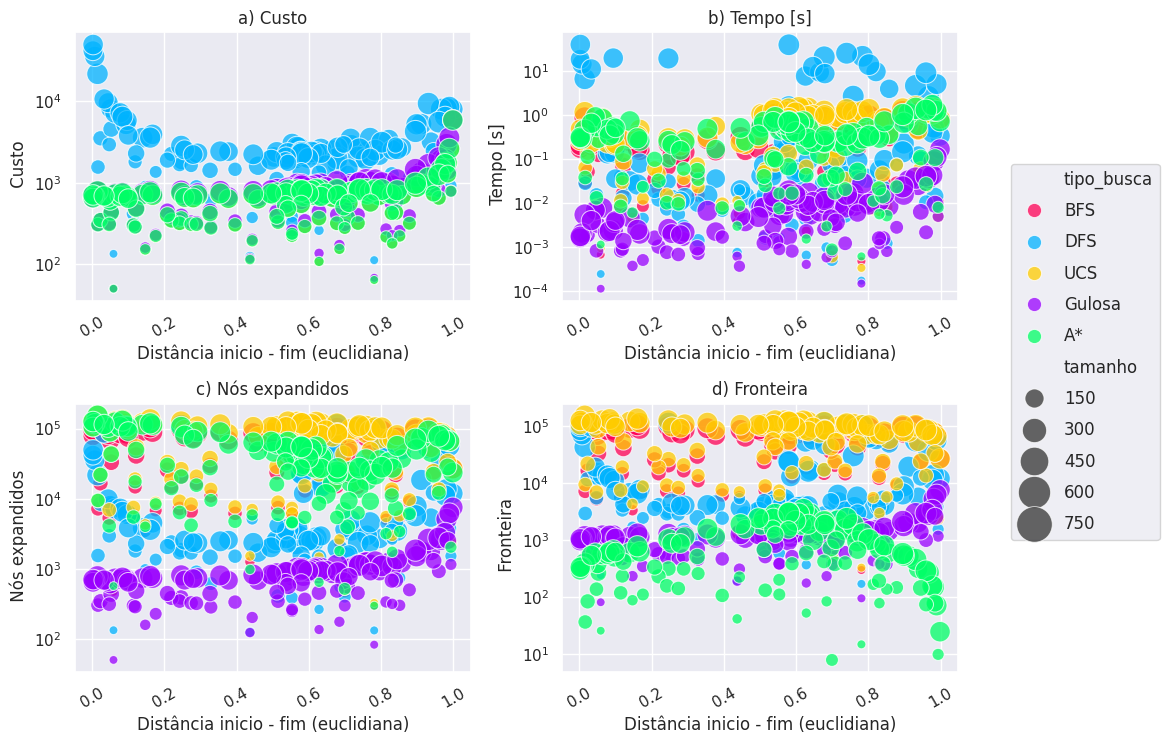

In [ ]:
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

cores_buscas = {
    "BFS": "#FF0055",      # Vermelho Ciano/Rosa Intenso
    "DFS": "#00B3FF",      # Azul Claro / Ciano
    "UCS": "#FFCC00",      # Amarelo Ouro
    "Gulosa": "#9900FF",   # Roxo / Violeta Escuro
    "A*": "#00FF66",       # Verde Brilhante / Menta
}

for ax, (coluna, titulo) in zip(axes, metricas.items()):
    sns.scatterplot(
        data=df,
        x="densidade",
        y=coluna,
        hue="tipo_busca",
        palette={busca: cores_buscas[busca] for busca in ordem_buscas},
        # sstyle="tipo_busca",
        # style_order=ordem_buscas,
        markers={busca: marcadores[busca] for busca in ordem_buscas},
        size="tamanho",
        sizes=(40, 260),
        alpha=0.75,
        ax=ax,
    )
    ax.set_title(f"{titulo}")
    ax.set_xlabel("Distância inicio - fim (euclidiana)")
    ax.set_ylabel(titulo.split(")")[1])
    # ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
legenda = fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    markerscale=1.7,
    fontsize=12,
    title_fontsize=13,
    labelspacing=0.8,
)

for handle in legenda.legend_handles:
    if hasattr(handle, "get_sizes") and hasattr(handle, "set_sizes"):
        handle.set_sizes(handle.get_sizes() * 1.8)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.savefig("figs/impacto_da_densidade_classicas.png", bbox_inches="tight", dpi=300)
plt.show()


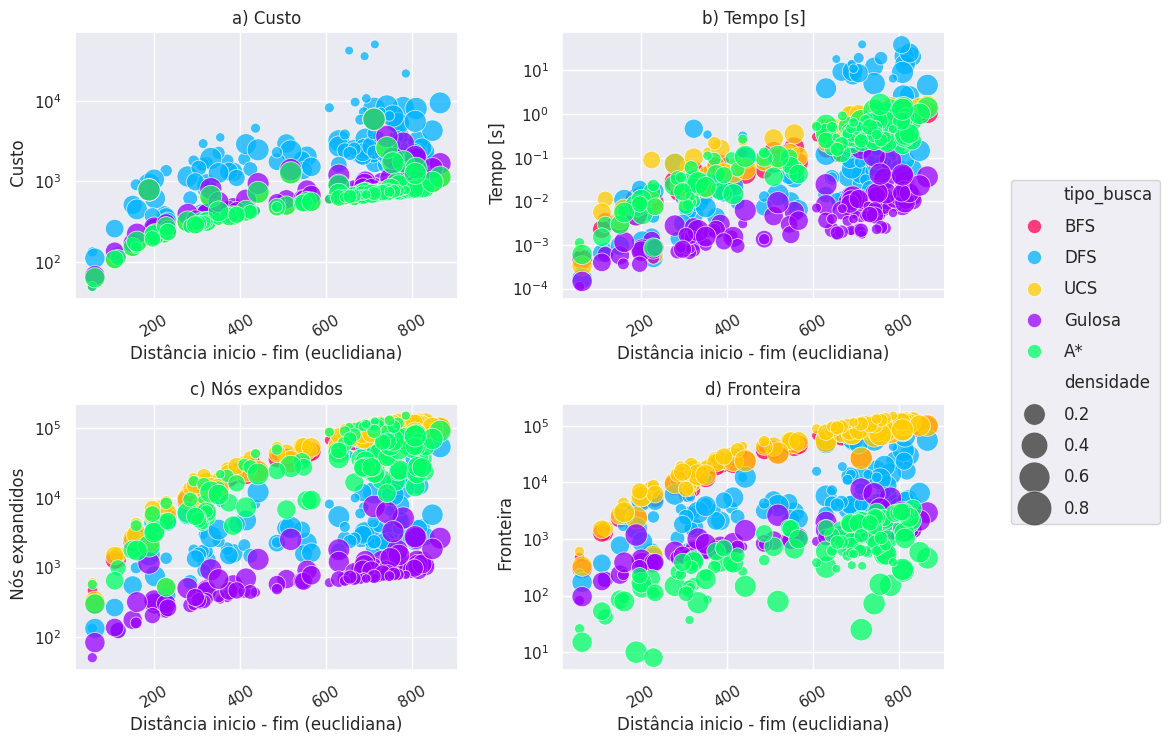

In [36]:
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

cores_buscas = {
    "BFS": "#FF0055",      # Vermelho Ciano/Rosa Intenso
    "DFS": "#00B3FF",      # Azul Claro / Ciano
    "UCS": "#FFCC00",      # Amarelo Ouro
    "Gulosa": "#9900FF",   # Roxo / Violeta Escuro
    "A*": "#00FF66",       # Verde Brilhante / Menta
}

for ax, (coluna, titulo) in zip(axes, metricas.items()):
    sns.scatterplot(
        data=df,
        x="tamanho",
        y=coluna,
        hue="tipo_busca",
        palette={busca: cores_buscas[busca] for busca in ordem_buscas},
        # sstyle="tipo_busca",
        # style_order=ordem_buscas,
        markers={busca: marcadores[busca] for busca in ordem_buscas},
        size="densidade",
        sizes=(40, 260),
        alpha=0.75,
        ax=ax,
    )
    ax.set_title(f"{titulo}")
    ax.set_xlabel("Distância inicio - fim (euclidiana)")
    ax.set_ylabel(titulo.split(")")[1])
    # ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
legenda = fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    markerscale=1.7,
    fontsize=12,
    title_fontsize=13,
    labelspacing=0.8,
)

for handle in legenda.legend_handles:
    if hasattr(handle, "get_sizes") and hasattr(handle, "set_sizes"):
        handle.set_sizes(handle.get_sizes() * 1.8)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.savefig("figs/impacto_do_tamanho_classicas.png", bbox_inches="tight", dpi=300)
plt.show()
